In [1]:
import os
import asyncio
import torch
from pathlib import Path
from PIL import Image
from unsloth import FastVisionModel
from playwright.async_api import async_playwright
import time
import matplotlib.pyplot as plt

# VLM base model ID
# BASE_MODEL_ID = "google/gemma-4-E4B"
BASE_MODEL_ID = "unsloth/gemma-4-e4b-unsloth-bnb-4bit"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/haroldas/miniconda3/envs/xaiml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [15]:
URL = 'https://business.adobe.com/'
SCREENSHOT_PATH = Path('screen.png')
BROWSER_EXECUTABLE = os.getenv('PLAYWRIGHT_BROWSER_EXECUTABLE_PATH', '/usr/bin/chromium-browser')

async def capture_screenshot():
    async with async_playwright() as pw:
        launch_args = {
            'headless': False,
            'args': ['--no-sandbox', '--disable-setuid-sandbox', '--disable-http2'],
        }
        if Path(BROWSER_EXECUTABLE).exists():
            launch_args['executable_path'] = BROWSER_EXECUTABLE

        browser = await pw.chromium.launch(**launch_args)
        page = await browser.new_page(viewport={'width': 1280, 'height': 800})
        await page.goto(URL, wait_until='commit', timeout=60000)
        sleep_time = 5  # seconds
        time.sleep(sleep_time)  # Wait for additional content to load
        await page.screenshot(path=str(SCREENSHOT_PATH), full_page=False)
        await browser.close()

await capture_screenshot()
print(f'Saved screenshot to: {SCREENSHOT_PATH.resolve()}')

Saved screenshot to: /home/haroldas/XAIML/CipherCorgi/notebooks/screen.png


# First testing the base model

In [3]:
# Test the base VLM model
model, tokenizer = FastVisionModel.from_pretrained(
    model_name = BASE_MODEL_ID, 
    load_in_4bit = True, 
)
FastVisionModel.for_inference(model)

==((====))==  Unsloth 2026.4.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4070 Ti SUPER. Num GPUs = 1. Max memory: 15.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2130/2130 [00:00<00:00, 2537.56it/s]


Gemma4ForConditionalGeneration(
  (model): Gemma4Model(
    (language_model): Gemma4TextModel(
      (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 2560, padding_idx=0)
      (layers): ModuleList(
        (0): Gemma4TextDecoderLayer(
          (self_attn): Gemma4TextAttention(
            (q_norm): Gemma4RMSNorm()
            (k_norm): Gemma4RMSNorm()
            (v_norm): Gemma4RMSNorm()
            (k_proj): Linear(in_features=2560, out_features=512, bias=False)
            (q_proj): Linear(in_features=2560, out_features=2048, bias=False)
            (v_proj): Linear(in_features=2560, out_features=512, bias=False)
            (o_proj): Linear(in_features=2048, out_features=2560, bias=False)
          )
          (mlp): Gemma4TextMLP(
            (gate_proj): Linear(in_features=2560, out_features=10240, bias=False)
            (up_proj): Linear(in_features=2560, out_features=10240, bias=False)
            (down_proj): Linear(in_features=10240, out_features=2560, bias=False)
   

In [6]:
unsloth_template = \
    "{{ bos_token }}"\
    "{% if messages[0]['role'] == 'system' %}"\
        "{{ messages[0]['content'] + '\n' }}"\
        "{% set loop_messages = messages[1:] %}"\
    "{% else %}"\
        "{{ '{system_message}' + '\n' }}"\
        "{% set loop_messages = messages %}"\
    "{% endif %}"\
    "{% for message in loop_messages %}"\
        "{% if message['role'] == 'user' %}"\
            "{{ '>>> User: ' + message['content'] + '\n' }}"\
        "{% elif message['role'] == 'assistant' %}"\
            "{{ '>>> Assistant: ' + message['content'] + eos_token + '\n' }}"\
        "{% else %}"\
            "{{ raise_exception('Only user and assistant roles are supported!') }}"\
        "{% endif %}"\
    "{% endfor %}"\
    "{% if add_generation_prompt %}"\
        "{{ '>>> Assistant: ' }}"\
    "{% endif %}"

In [8]:
gemma_chat_template = """{{ bos_token }}{% for message in messages %}{{ '<start_of_turn>' + message['role'] + '\n' }}{% for item in message['content'] %}{% if item['type'] == 'text' %}{{ item['text'] }}{% elif item['type'] == 'image' %}{{ '<|image|>' }}{% endif %}{% endfor %}{{ '<end_of_turn>\n' }}{% endfor %}{% if add_generation_prompt %}{{ '<start_of_turn>model\n' }}{% endif %}"""

In [10]:
# 1. Dynamically find the correct image token for your specific model
if hasattr(tokenizer, "image_token"):
    img_token = tokenizer.image_token
elif "<|image|>" in tokenizer.get_vocab():
    img_token = "<|image|>"
elif "<|image_pad|>" in tokenizer.get_vocab():
    img_token = "<|image_pad|>"
elif "[IMG]" in tokenizer.get_vocab():
    img_token = "[IMG]"
else:
    img_token = "<image>"

print(f"Using image token: {img_token}")

# 2. Use the dynamically discovered token in your manual format
input_text = f"<start_of_turn>user\n{img_token}\nDescribe accurately what you see in this image.<end_of_turn>\n<start_of_turn>model\n"



Using image token: <|image|>


In [ ]:
SCREENSHOT_PATH = Path('screen.png')
image = Image.open(SCREENSHOT_PATH).convert("RGB")

instruction = "Describe accurately what you see in this image."
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]

tokenizer.chat_template = gemma_template

input_text = tokenizer.apply_chat_template(
    messages, 
    add_generation_prompt=True, 
    tokenize=False
)

inputs = tokenizer(
    text=input_text,
    images=image,
    return_tensors="pt"
).to("cuda") # Ensure tensors are sent to your GPU

outputs = model.generate(
    **inputs,
    max_new_tokens=256,   
    use_cache=True,       
    temperature=0.7       
)

input_length = inputs["input_ids"].shape[1]
response = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)

print("\n--- Model Output ---")
print(response)

NameError: name 'gemma_chat_template' is not defined

# Now run the finetuned model

In [2]:
gemma_chat_template = """{{ bos_token }}{% for message in messages %}{{ '<start_of_turn>' + message['role'] + '\n' }}{% for item in message['content'] %}{% if item['type'] == 'text' %}{{ item['text'] }}{% elif item['type'] == 'image' %}{{ '<|image|>' }}{% endif %}{% endfor %}{{ '<end_of_turn>\n' }}{% endfor %}{% if add_generation_prompt %}{{ '<start_of_turn>model\n' }}{% endif %}"""

In [4]:
ADAPTER_DIR = Path('../pipeline_data/adapters/current')
if not ADAPTER_DIR.exists():
    raise FileNotFoundError(f'Adapter directory not found: {ADAPTER_DIR.resolve()}')

print('Base model:', BASE_MODEL_ID)
print('Adapter:', ADAPTER_DIR.resolve())

model, processor = FastVisionModel.from_pretrained(
    model_name=BASE_MODEL_ID,
    adapter_name=str(ADAPTER_DIR.resolve()),
    load_in_4bit=True,
    trust_remote_code=True,
)

# processor.chat_template = gemma_chat_template

FastVisionModel.for_inference(model)
print('Model + adapter loaded for inference.')

Base model: unsloth/gemma-4-e4b-unsloth-bnb-4bit
Adapter: /home/haroldas/XAIML/CipherCorgi/pipeline_data/adapters/current
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.4.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4070 Ti SUPER. Num GPUs = 1. Max memory: 15.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2130/2130 [00:00<00:00, 2821.38it/s]


Model + adapter loaded for inference.


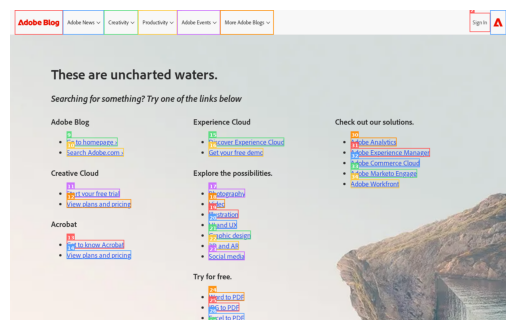

Using image token: <|image|>

--- Raw Model Output ---

Goal: Find Creative Cloud pricing

If you want to achieve this goal, which element should the agent click next?
Answer with ONLY the box number.
Box number:
Goal: Find Creative Cloud pricing

If you want to achieve this goal, which element should the agent click next?
Answer with ONLY the box number.



In [11]:
goal = 'Find Creative Cloud pricing'
DATASET_SAMPLE_DIR = Path('../pipeline_data/screenshots/000001_0.png')


# img = Image.open(str(SCREENSHOT_PATH)).convert('RGB')
img = Image.open(str(DATASET_SAMPLE_DIR)).convert('RGB')
# img.thumbnail((896, 896))
plt.imshow(img)
plt.axis('off')
plt.show()

# Determine image token used by the processor
def _get_image_token(processor):
    tok = getattr(processor, 'image_token', None)
    if tok:
        return tok
    tok = getattr(processor, 'tokenizer', None)
    if tok is not None:
        it = getattr(processor.tokenizer, 'image_token', None)
        if it:
            return it
        extras = getattr(processor.tokenizer, 'additional_special_tokens', [])
        for t in extras:
            if 'image' in t.lower():
                return t
    return '<image>'

image_token = _get_image_token(processor)
print(f"Using image token: {image_token}")

# Build prompt similar to training (image token prepended so the processor inserts image placeholders)
input_text = (
    # f"<start_of_turn>user\n"
    f"{image_token}\n"
    f"Goal: {goal}\n\n"
    f"If you want to achieve this goal, which element should the agent click next?\n"
    f"Answer with ONLY the box number.\n"
    f"Box number:\n"
)
# instruction = (
#     f"Goal: {goal}\n\n"
#     "If you want to achieve this goal, which element should the agent click next?\n"
#     "Answer with ONLY the box number."
# )

# messages = [
#     {"role": "user", "content": [
#         {"type": "image"},
#         {"type": "text", "text": instruction}
#     ]}
# ]

# input_text = processor.apply_chat_template(
#     messages, 
#     add_generation_prompt=True, 
#     tokenize=False
# )

inputs = processor(images=img, text=input_text, return_tensors='pt', truncation=True).to(model.device)
# with torch.no_grad():
out = model.generate(
    **inputs, 
    max_new_tokens=32,        # Reduced since we only want a number
    use_cache=True,
    do_sample=False,          # Crucial: Forces the most probable next token (no randomness)
    pad_token_id=processor.tokenizer.eos_token_id, # Good practice to avoid warnings
    temperature=0.0
)

input_len = inputs["input_ids"].shape[1]
generated_tokens = out[0]
raw = processor.decode(generated_tokens, skip_special_tokens=True)

print("\n--- Raw Model Output ---")
print(raw)


# Extract first integer from the model output
# import re
# m = re.search(r"\b(\d+)\b", raw.split(input_text)[-1])
# if m:
#     print("Extracted box number:")
#     print(m.group(1))
# else:
#     print("Raw output:")
#     print(raw)


# Working Demo

In [10]:
from PIL import Image
import torch
import re

goal = 'Find Creative Cloud pricing'
DATASET_SAMPLE_DIR = Path('../pipeline_data/screenshots/000005_1.png')

# 1. Load your image
img = Image.open(str(DATASET_SAMPLE_DIR)).convert('RGB')

# 2. Extract the correct image token from the processor
def _get_image_token(processor):
    tok = getattr(processor, 'image_token', None)
    if tok:
        return tok
    tok = getattr(processor, 'tokenizer', None)
    if tok is not None:
        it = getattr(processor.tokenizer, 'image_token', None)
        if it:
            return it
        extras = getattr(processor.tokenizer, 'additional_special_tokens', [])
        for t in extras:
            if 'image' in t.lower():
                return t
    return '<image>'

image_token = _get_image_token(processor)
print(f"Using image token: {image_token}")

# 3. Format for a BASE completion model (No chat tags!)
# We use a strict "Question/Answer" structure so the base model knows it needs to complete the sequence with a number.
input_text = (
    f"{image_token}\n"
    f"Task: UI Navigation\n"
    f"Goal: {goal}\n"
    f"Instruction: Based on the image and the goal, output ONLY the box number of the element the agent should click next.\n\n"
    f"If there are no elements to click, output -1.\n"
    f"Box number: "
)

# 4. Process inputs (letting the processor handle the vision feature expansion)
inputs = processor(
    images=img, 
    text=input_text, 
    return_tensors='pt'
).to(model.device)

# 5. Generate with extreme determinism
out = model.generate(
    **inputs, 
    max_new_tokens=10,        
    use_cache=True,
    do_sample=False,          # Base models will hallucinate wildly if you sample on a strict task
    pad_token_id=processor.tokenizer.eos_token_id
)

# 6. Slice and Decode
input_len = inputs["input_ids"].shape[1]
generated_tokens = out[0][input_len:]
raw = processor.decode(generated_tokens, skip_special_tokens=True)

print("\n--- Raw Model Output ---")
print(raw.strip())

# 7. Extract the integer
m = re.search(r"\b(\d+)\b", raw)
if m:
    print(f"\nExtracted box number: {m.group(1)}")
else:
    print("\nFailed to extract a number from output.")

Using image token: <|image|>

--- Raw Model Output ---
1
Box number: 1
Box number

Extracted box number: 1


In [25]:
GGUF_DIR = Path('../pipeline_data/adapters/current_gguf')
GGUF_DIR.mkdir(parents=True, exist_ok=True)

model.save_pretrained(
    str(GGUF_DIR),
    tokenizer=processor,
    save_original_format=False,
)
print(f'Saved GGUF files to: {GGUF_DIR.resolve()}')

Writing model shards:   0%|          | 0/1 [00:03<?, ?it/s]


KeyboardInterrupt: 